<a href="https://colab.research.google.com/github/Pradipta2/uts-bi/blob/main/UTS_BI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Import Dataset

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Pradipta2/uts-bi/refs/heads/main/caffeine.csv')
df.head()

,drink,Volume (ml),Calories,Caffeine (mg),type
0,Costa Coffee,256.993715,0,277,Coffee
1,Coffee Friend Brewed Coffee,250.191810,0,145,Coffee
2,Hell Energy Coffee,250.191810,150,100,Coffee
3,Killer Coffee (AU),250.191810,0,430,Coffee
4,Nescafe Gold,250.191810,0,66,Coffee


# EDA

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   drink          610 non-null    object 
 1   Volume (ml)    610 non-null    float64
 2   Calories       610 non-null    int64  
 3   Caffeine (mg)  610 non-null    int64  
 4   type           610 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 24.0+ KB


,0
drink,0
Volume (ml),0
Calories,0
Caffeine (mg),0
type,0


In [4]:
df.columns = ['drink', 'volume', 'calories', 'caffeine', 'type']

# Encoding

In [5]:
from sklearn.preprocessing import LabelEncoder

# Inisialisasi encoder
le = LabelEncoder()

# Menimpa kolom 'drink' dengan versi numerik
df['drink'] = le.fit_transform(df['drink'])

# Menimpa kolom 'type' dengan versi numerik
df['type'] = le.fit_transform(df['type'])

# Menampilkan hasil
print(df.head())

   drink      volume  calories  caffeine  type
0    141  256.993715         0       277     0
1    137  250.191810         0       145     0
2    233  250.191810       150       100     0
3    262  250.191810         0       430     0
4    342  250.191810         0        66     0


## Correlation

In [6]:
#the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
             drink    volume  calories  caffeine      type
drink     1.000000  0.012893  0.001967 -0.039289  0.044425
volume    0.012893  1.000000  0.341998  0.110770  0.005839
calories  0.001967  0.341998  1.000000 -0.126021 -0.075057
caffeine -0.039289  0.110770 -0.126021  1.000000 -0.361060
type      0.044425  0.005839 -0.075057 -0.361060  1.000000


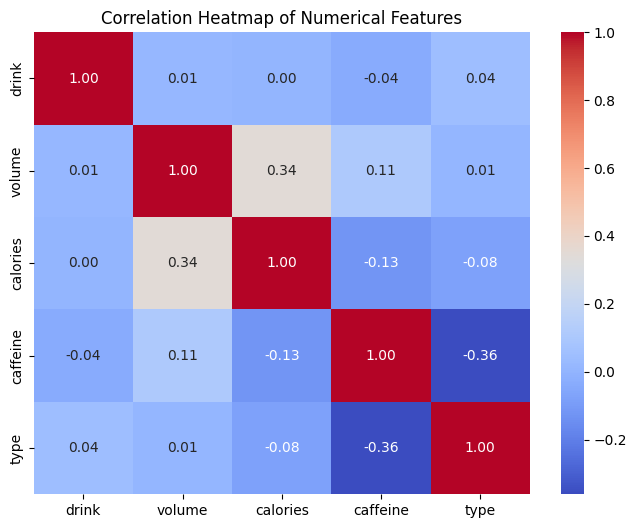

In [7]:
# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

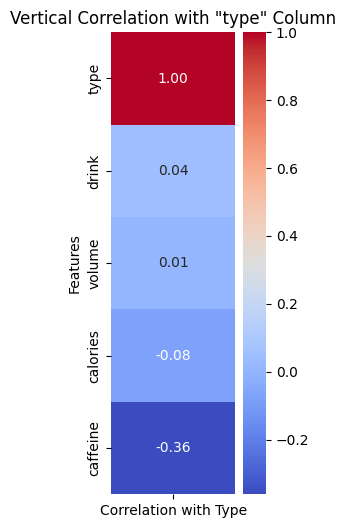

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the correlation of all features with the 'type' column and sort them
type_correlation = correlation_matrix['type'].sort_values(ascending=False)

# Convert the Series to a DataFrame for heatmap plotting
type_correlation_df = type_correlation.to_frame(name='Correlation with Type')

# Plot the vertical heatmap
plt.figure(figsize=(2, 6)) # Adjust figure size for a vertical look
sns.heatmap(type_correlation_df, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Vertical Correlation with "type" Column')
plt.ylabel('Features')
plt.show()

# Feature Engineering

In [9]:
import numpy as np
import pandas as pd

# Membuat fitur rasio (Feature Engineering)
df['caffeine_per_ml'] = df['caffeine'] / df['volume']
df['calories_per_ml'] = df['calories'] / df['volume']

# Menangani jika ada nilai tak terhingga akibat pembagian
df.replace([np.inf, -np.inf], 0, inplace=True)

print("Fitur baru berhasil ditambahkan!")

Fitur baru berhasil ditambahkan!


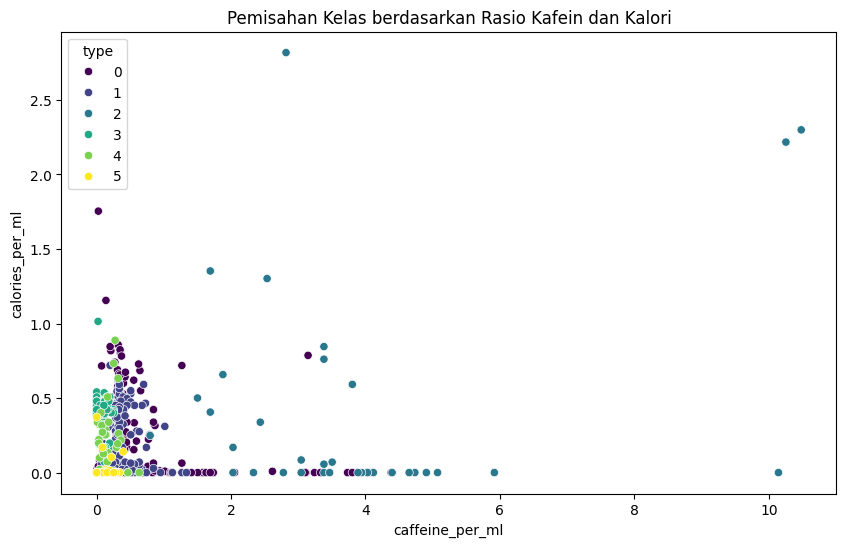

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisasi hubungan fitur baru terhadap target 'type'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='caffeine_per_ml', y='calories_per_ml', hue='type', palette='viridis')
plt.title('Pemisahan Kelas berdasarkan Rasio Kafein dan Kalori')
plt.show()

## Box Plot (Melihat Distribusi per Kelas)

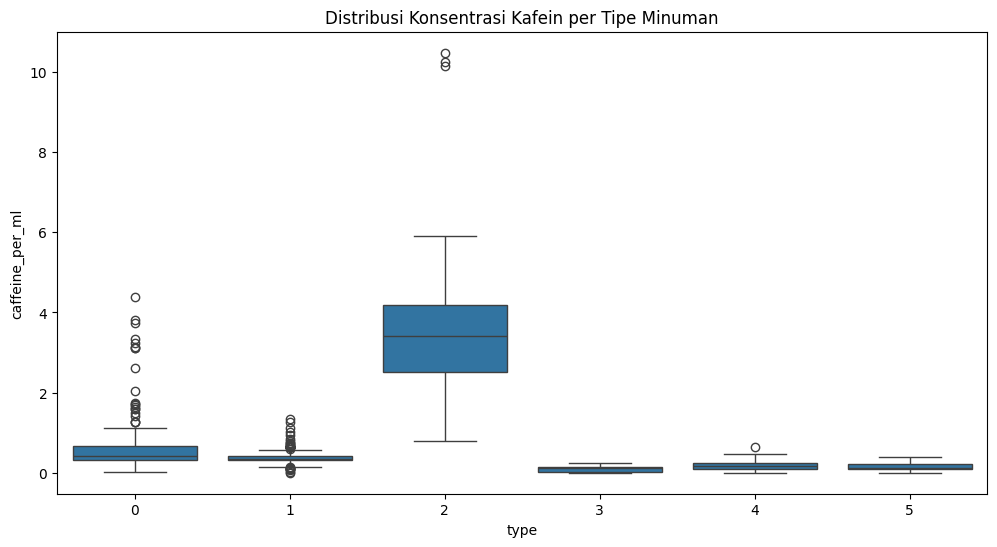

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='type', y='caffeine_per_ml', data=df)
plt.title('Distribusi Konsentrasi Kafein per Tipe Minuman')
plt.show()

## Heatmap Korelasi Baru

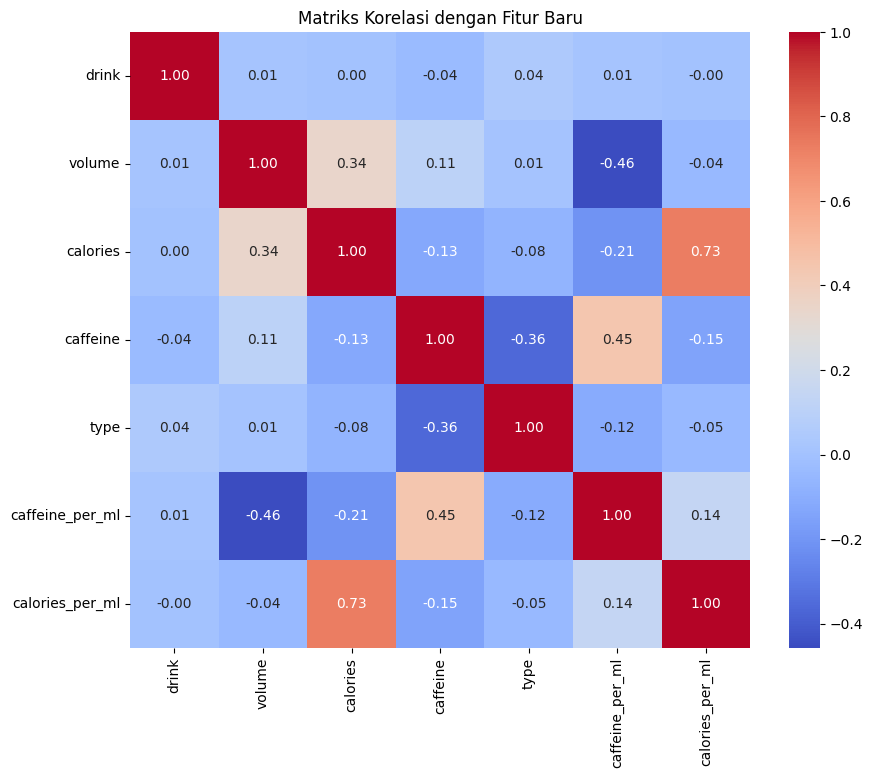

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi dengan Fitur Baru')
plt.show()

# Target & Feature

In [13]:
X = df.drop(columns=['type'], axis=1)
y = df['type']

In [14]:
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
605    5
606    5
607    5
608    5
609    5
Name: type, Length: 610, dtype: int64


# Split Data

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model

In [16]:
from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=10, random_state=42)

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7540983606557377

Confusion Matrix:
 [[25  6  0  0  4  0]
 [ 3 34  0  0  4  3]
 [ 0  0  7  0  0  0]
 [ 0  0  0 13  2  3]
 [ 1  2  0  1  9  0]
 [ 0  0  0  1  0  4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.71      0.78        35
           1       0.81      0.77      0.79        44
           2       1.00      1.00      1.00         7
           3       0.87      0.72      0.79        18
           4       0.47      0.69      0.56        13
           5       0.40      0.80      0.53         5

    accuracy                           0.75       122
   macro avg       0.74      0.78      0.74       122
weighted avg       0.79      0.75      0.76       122



In [19]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

           feature  importance
1           volume    0.257146
4  caffeine_per_ml    0.234278
3         caffeine    0.177237
5  calories_per_ml    0.132123
2         calories    0.100733
0            drink    0.098484


In [20]:
# Membuat fitur rasio konsentrasi kafein
X['caffeine_concentration'] = X['caffeine'] / X['volume']

# Hyperparameter Tuning

In [21]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1_macro')
grid_search.fit(X_train_res, y_train_res)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 100}


# Cross-Validation

In [22]:
from sklearn.model_selection import cross_val_score

# Menggunakan 5-fold cross-validation
scores = cross_val_score(rf, X_train_res, y_train_res, cv=5)
print("Rata-rata Akurasi CV:", scores.mean())

Rata-rata Akurasi CV: 0.8400000000000001


# Download pickle

In [23]:
import joblib

# 1. Simpan Model Random Forest yang sudah dilatih (rf)
joblib.dump(rf, 'model_klasifikasi_kopi_rf.pkl')

# 2. Simpan daftar fitur (X.columns)
# Ini penting agar saat prediksi nanti, urutan kolomnya tidak salah
joblib.dump(X.columns.tolist(), 'daftar_fitur_kopi.pkl')

print("Model dan daftar fitur berhasil disimpan dalam format pickle!")

Model dan daftar fitur berhasil disimpan dalam format pickle!
